In [38]:
import glob, os
import time
import numpy as np
import xarray as xr
from scipy.ndimage import uniform_filter
import matplotlib.pyplot as plt
import matplotlib as mpl
%matplotlib inline

mpl.rcParams['figure.dpi'] = 150

In [5]:
in_dir = "/gpfs/wolf2/arm/cli120/world-shared/d3m088/cacti/staged_runs_2/20190123/gefs18/base/les/subset_d3/"
methamsl_filebase = "corlasso_methamsl_2019012300gefs18d3_base_M1.m1."
cldhamsl_filebase = "corlasso_cldhamsl_2019012300gefs18d3_base_M1.m1."
methamsl_filename = f"{in_dir}{methamsl_filebase}20190123.171500.nc"
cldhamsl_filename = f"{in_dir}{cldhamsl_filebase}20190123.171500.nc"

In [ ]:
dsm = xr.open_dataset(methamsl_filename)
HAMSL = dsm['HAMSL']
dsm

<xarray.Dataset> Size: 1GB
Dimensions:      (Time: 1, south_north: 865, west_east: 750, HAMSL: 40)
Coordinates:
  * Time         (Time) datetime64[ns] 8B 2019-01-23T17:15:00
    XLONG        (south_north, west_east) float32 3MB ...
    XLAT         (south_north, west_east) float32 3MB ...
    XTIME        (Time) float32 4B ...
  * HAMSL        (HAMSL) float64 320B 250.0 500.0 750.0 ... 2e+04 2.1e+04
Dimensions without coordinates: south_north, west_east
Data variables: (12/41)
    ITIMESTEP    (Time) int32 4B ...
    HGT          (Time, south_north, west_east) float32 3MB ...
    MUTOT        (Time, south_north, west_east) float32 3MB ...
    PRESSURE     (Time, HAMSL, south_north, west_east) float32 104MB ...
    ALT          (Time, HAMSL, south_north, west_east) float32 104MB ...
    TEMPERATURE  (Time, HAMSL, south_north, west_east) float32 104MB ...
    ...           ...
    MULCL        (Time, south_north, west_east) float32 3MB ...
    MULFC        (Time, south_north, west_east) float32 3MB ...
    MULNB        (Time, south_north, west_east) float32 3MB ...
    MULPL        (Time, south_north, west_east) float32 3MB ...
    MUCAPE       (Time, south_north, west_east) float32 3MB ...
    MUCIN        (Time, south_north, west_east) float32 3MB ...
Attributes: (12/39)
    DX:                          500.0
    DY:                          500.0
    SIMULATION_START_DATE:       2019-01-23_06:00:00
    WEST-EAST_GRID_DIMENSION:    751
    SOUTH-NORTH_GRID_DIMENSION:  866
    BOTTOM-TOP_GRID_DIMENSION:   150
    ...                          ...
    doi_isPartOf_lasso-cacti:    https://doi.org/10.5439/1905789
    doi_isDocumentedBy:          https://doi.org/10.2172/1905845
    doi_thisFileType:            https://doi.org/10.5439/1905823
    history:                     processed by user d3m088 on machine cirrus17...
    filename_user:               corlasso_methamsl_2019012300gefs18d3_base_M1...
    filename_storage:            corlassomethamsl2019012300gefs18d3baseM1.m1....

In [7]:
dsc = xr.open_dataset(cldhamsl_filename)
dsc

<xarray.Dataset> Size: 1GB
Dimensions:      (Time: 1, south_north: 865, west_east: 750, HAMSL: 40)
Coordinates:
  * Time         (Time) datetime64[ns] 8B 2019-01-23T17:15:00
    XLONG        (south_north, west_east) float32 3MB ...
    XLAT         (south_north, west_east) float32 3MB ...
    XTIME        (Time) float32 4B ...
  * HAMSL        (HAMSL) float64 320B 250.0 500.0 750.0 ... 2e+04 2.1e+04
Dimensions without coordinates: south_north, west_east
Data variables: (12/14)
    ITIMESTEP    (Time) int32 4B ...
    QCLOUD       (Time, HAMSL, south_north, west_east) float32 104MB ...
    QRAIN        (Time, HAMSL, south_north, west_east) float32 104MB ...
    QICE         (Time, HAMSL, south_north, west_east) float32 104MB ...
    QSNOW        (Time, HAMSL, south_north, west_east) float32 104MB ...
    QGRAUP       (Time, HAMSL, south_north, west_east) float32 104MB ...
    ...           ...
    REFL_10CM    (Time, HAMSL, south_north, west_east) float32 104MB ...
    CLDFRA       (Time, HAMSL, south_north, west_east) float32 104MB ...
    LWP          (Time, south_north, west_east) float32 3MB ...
    IWP          (Time, south_north, west_east) float32 3MB ...
    PRECIPWATER  (Time, south_north, west_east) float32 3MB ...
    QNCLOUD      (Time, HAMSL, south_north, west_east) float32 104MB ...
Attributes: (12/39)
    DX:                          500.0
    DY:                          500.0
    SIMULATION_START_DATE:       2019-01-23_06:00:00
    WEST-EAST_GRID_DIMENSION:    751
    SOUTH-NORTH_GRID_DIMENSION:  866
    BOTTOM-TOP_GRID_DIMENSION:   150
    ...                          ...
    doi_isPartOf_lasso-cacti:    https://doi.org/10.5439/1905789
    doi_isDocumentedBy:          https://doi.org/10.2172/1905845
    doi_thisFileType:            https://doi.org/10.5439/1905816
    history:                     processed by user d3m088 on machine cirrus13...
    filename_user:               corlasso_cldhamsl_2019012300gefs18d3_base_M1...
    filename_storage:            corlassocldhamsl2019012300gefs18d3baseM1.m1....

In [9]:
def coarsen_variable_filter(in_variable, ratio):
    """
    Efficiently coarsen a generic variable using uniform_filter with straight averaging.
    Optimized for large arrays with minimal memory usage.
    
    Args:
        in_variable: np.array (3D: z,y,x or 2D: y,x)
            Input variable array
        ratio: int
            Coarsening ratio (e.g., 5 means 5x5 averaging)
    
    Returns:
        out_variable: np.array
            Coarsened variable array
    """
    # Create mask for valid values (handle NaN efficiently)
    mask = ~np.isnan(in_variable)
    
    # Replace NaN with 0 for filtering (in-place to save memory)
    filtered_var = np.where(mask, in_variable, 0.0)
    
    # Set filter size based on dimensions
    if in_variable.ndim == 3:
        filter_size = (1, ratio, ratio)  # Don't average in z-direction
    else:
        filter_size = (ratio, ratio)
    
    # Apply uniform filter to both data and mask
    # Use float32 to save memory if input precision allows
    dtype = np.float32 if in_variable.dtype in [np.float32, np.int32, np.int16] else np.float64
    
    var_sum = uniform_filter(filtered_var.astype(dtype), size=filter_size, mode='constant')
    count_sum = uniform_filter(mask.astype(dtype), size=filter_size, mode='constant')
    
    # Subsample to get final coarsened grid
    start_idx = ratio // 2
    if in_variable.ndim == 3:
        var_coarse = var_sum[:, start_idx::ratio, start_idx::ratio]
        count_coarse = count_sum[:, start_idx::ratio, start_idx::ratio]
    else:
        var_coarse = var_sum[start_idx::ratio, start_idx::ratio]
        count_coarse = count_sum[start_idx::ratio, start_idx::ratio]
    
    # Calculate average where we have valid data
    out_variable = np.full_like(var_coarse, np.nan, dtype=np.float32)
    valid_mask = count_coarse > 0
    out_variable[valid_mask] = var_coarse[valid_mask] / count_coarse[valid_mask]
    
    return out_variable

def coarsen_reflectivity_filter(in_reflectivity, ratio):
    """
    Efficiently coarsen using uniform_filter.
    """
    # Convert to linear
    mask = ~np.isnan(in_reflectivity)
    linear_refl = np.where(mask, 10.0 ** (in_reflectivity / 10.0), 0.0)
    
    if in_reflectivity.ndim == 3:
        filter_size = (1, ratio, ratio)  # Don't average in z-direction
    else:
        filter_size = (ratio, ratio)
    
    # Apply uniform filter
    linear_avg = uniform_filter(linear_refl.astype(np.float64), size=filter_size, mode='constant')
    count_avg = uniform_filter(mask.astype(np.float64), size=filter_size, mode='constant')
    
    # Subsample
    start_idx = ratio // 2
    if in_reflectivity.ndim == 3:
        linear_coarse = linear_avg[:, start_idx::ratio, start_idx::ratio]
        count_coarse = count_avg[:, start_idx::ratio, start_idx::ratio]
    else:
        linear_coarse = linear_avg[start_idx::ratio, start_idx::ratio]
        count_coarse = count_avg[start_idx::ratio, start_idx::ratio]
    
    # Convert back to dB
    out_reflectivity = np.full_like(linear_coarse, np.nan, dtype=np.float32)
    valid_mask = count_coarse > 0
    out_reflectivity[valid_mask] = 10.0 * np.log10(linear_coarse[valid_mask] / count_coarse[valid_mask])
    
    return out_reflectivity

In [28]:
ratio = 5
# dsm['WA'].squeeze().values.shape
WA = coarsen_variable_filter(dsm['WA'].squeeze().values, ratio)
WA.shape

(40, 173, 150)

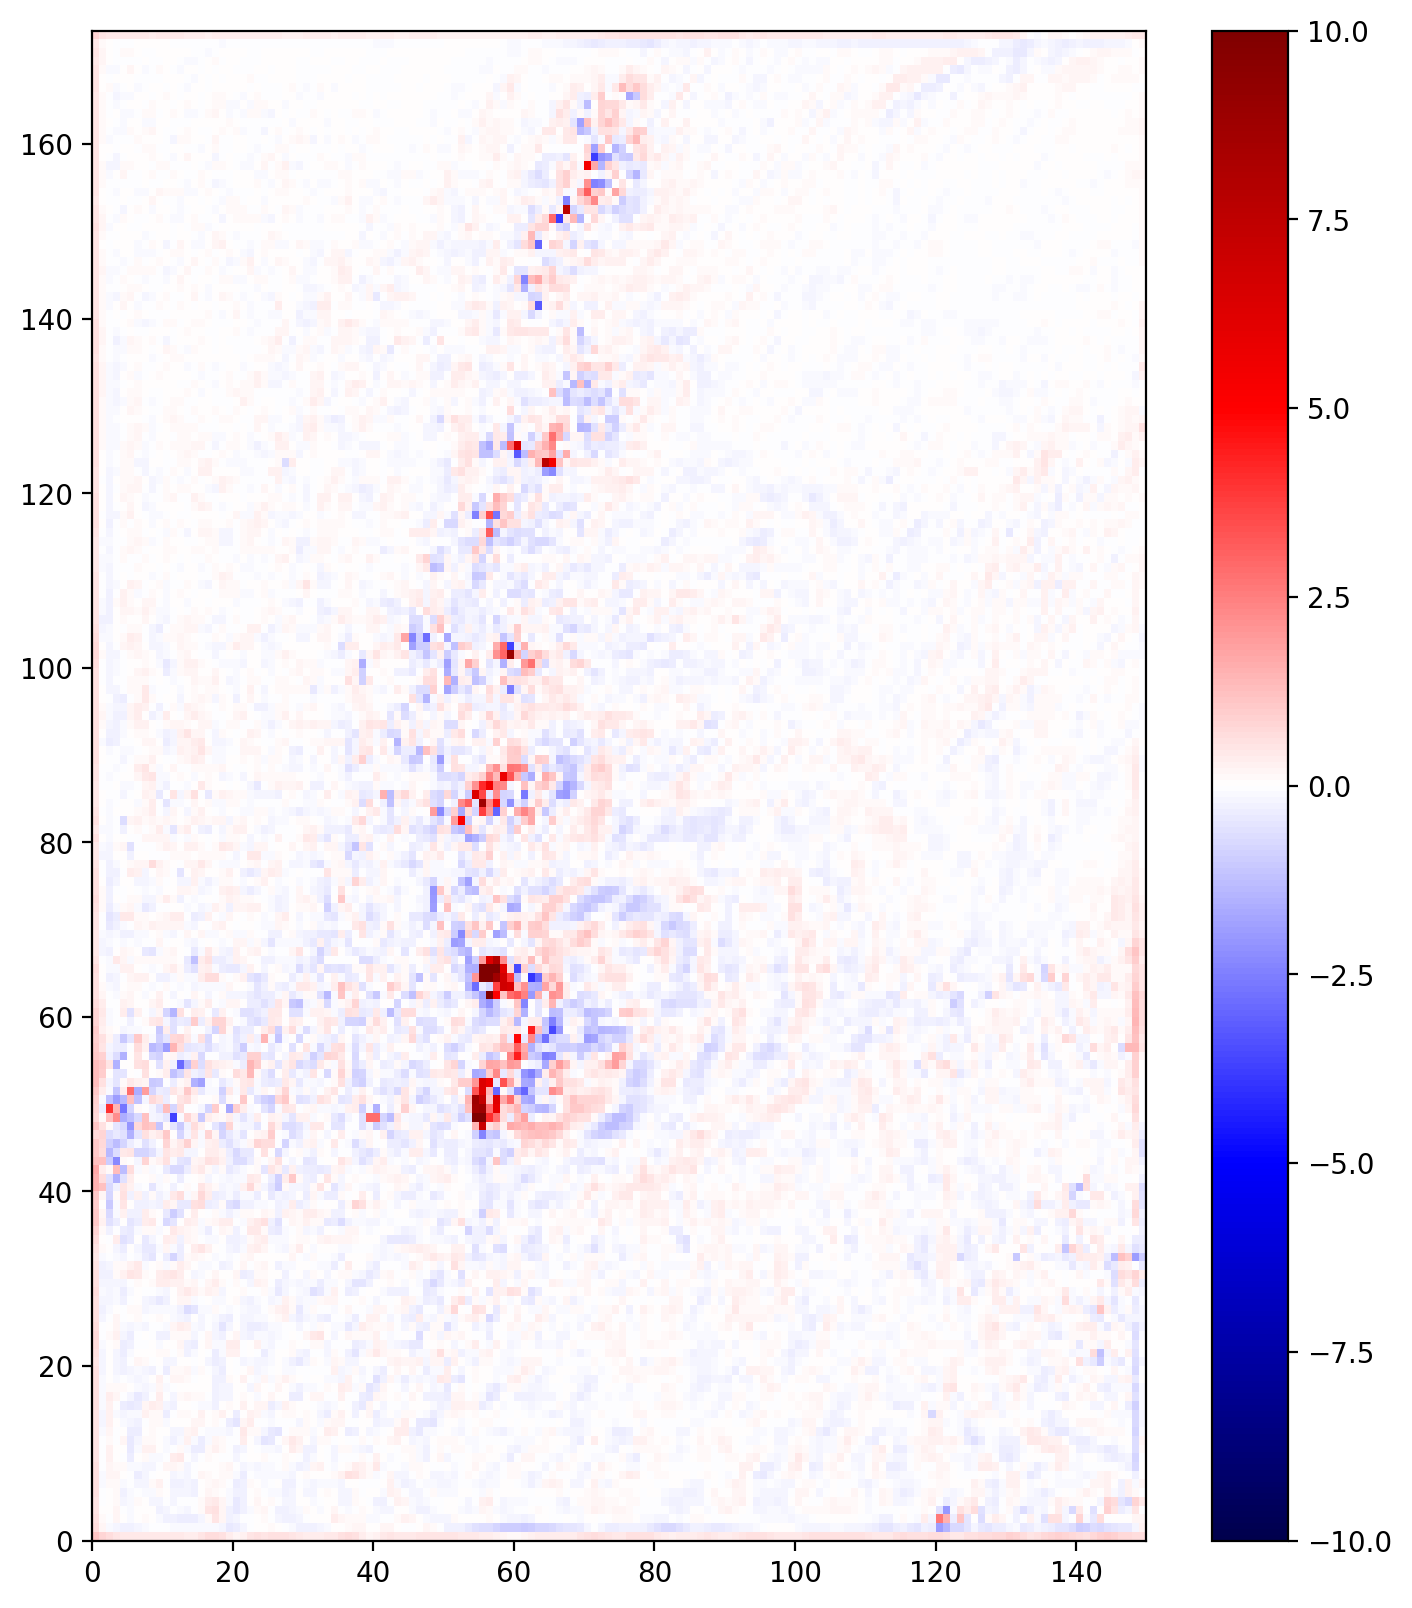

In [40]:
z_idx = np.where(HAMSL==6000)[0]

WA_z = WA[z_idx,:,:].squeeze()

fig = plt.figure(figsize=[8.5,10], dpi=200)
plt.pcolormesh(WA_z, vmin=-10, vmax=10, cmap='seismic')
plt.colorbar()

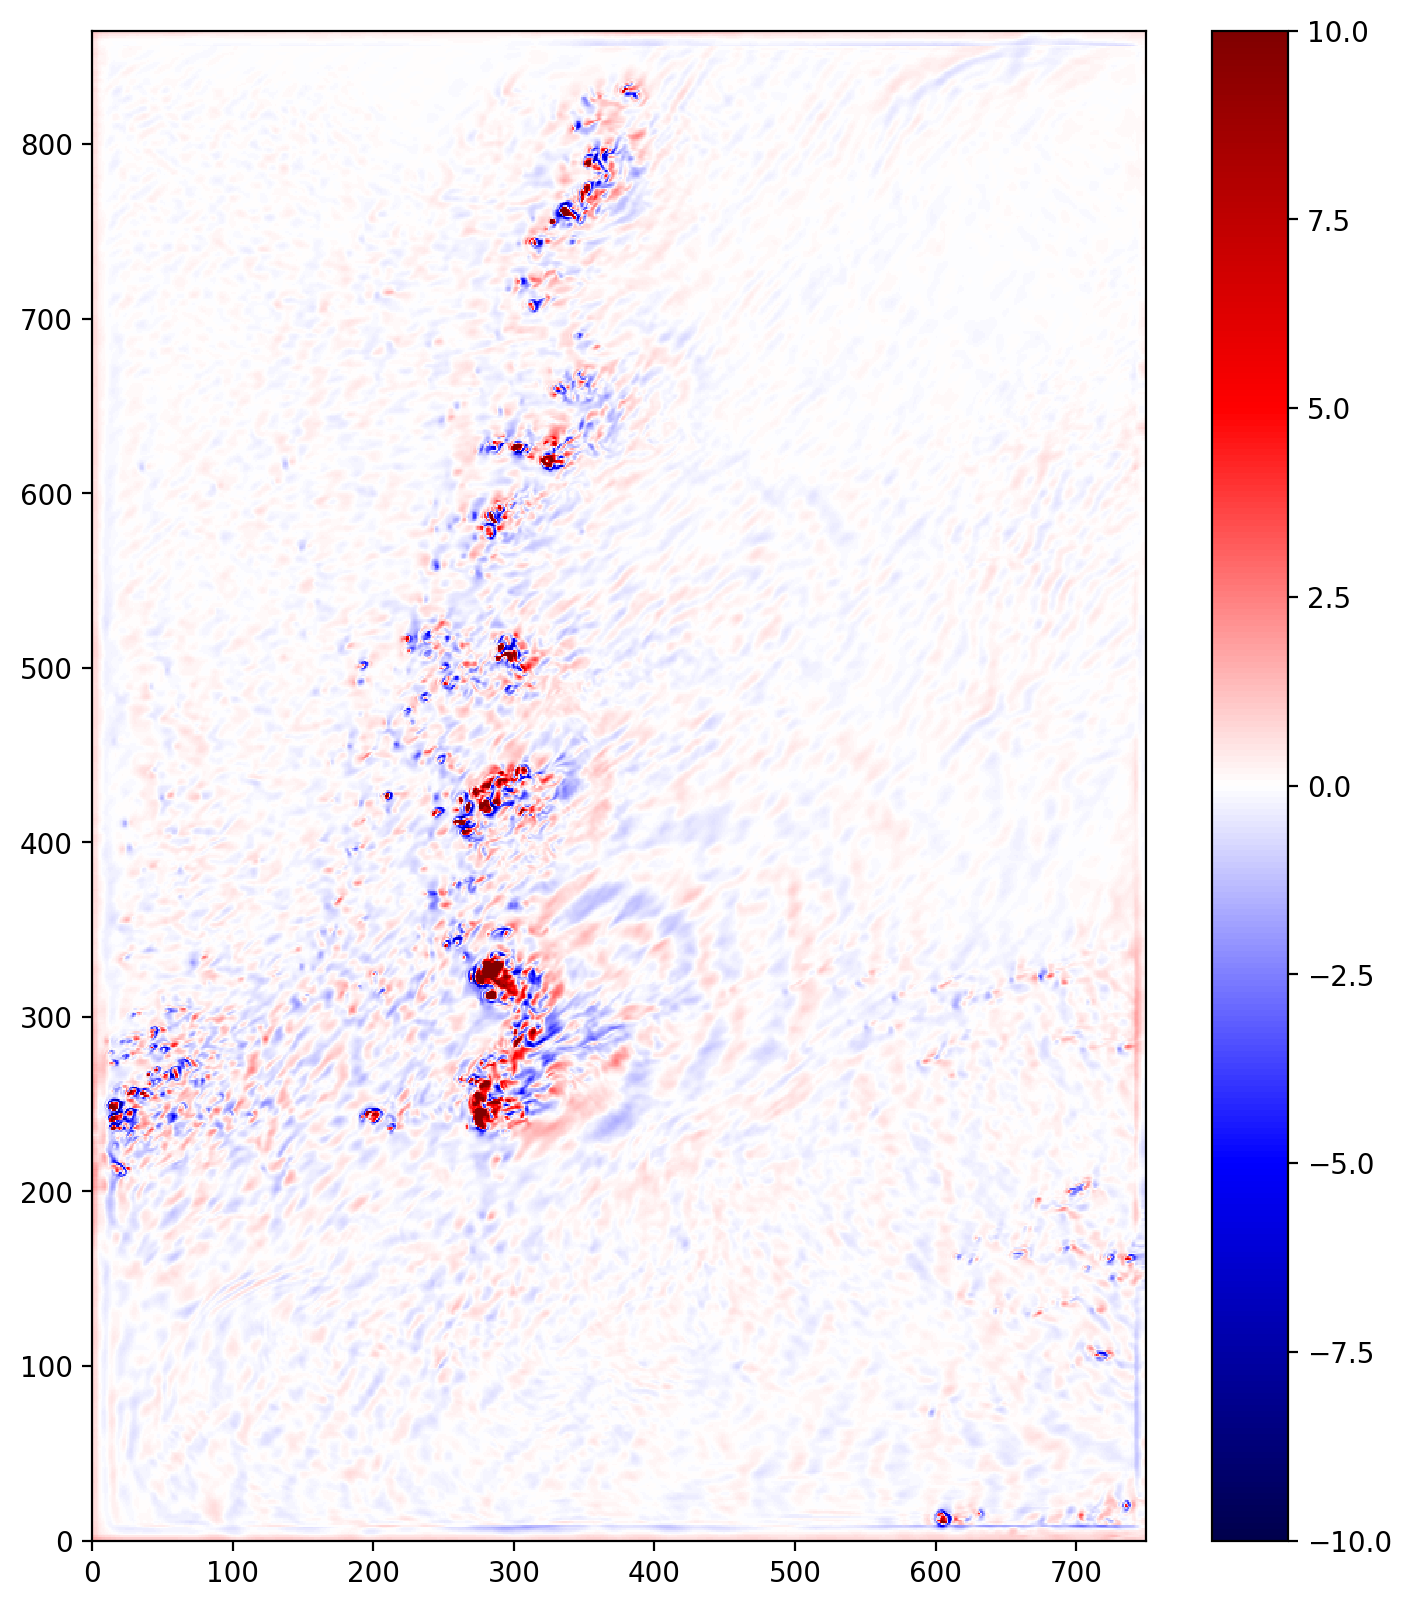

In [ ]:
fig = plt.figure(figsize=[8.5,10], dpi=200)
plt.pcolormesh(dsm['WA'].squeeze()[z_idx,:,:].squeeze(), vmin=-10, vmax=10, cmap='seismic')
plt.colorbar()